# Анализ лояльности пользователей Яндекс Афиши

## Введение

Команда маркетинга Яндекс Афиши хочет лучше понимать поведение пользователей и определить, какие характеристики связаны с повторными заказами.

Результаты исследования могут помочь:
- находить перспективные сегменты пользователей;
- точнее настраивать рекламу;
- рациональнее распределять маркетинговый бюджет;
- повышать удержание клиентов.

**Цель исследования:** изучить характеристики первого заказа и дальнейшее поведение пользователей, а также определить признаки, которые связаны с количеством заказов и возвратом на платформу.

Для анализа данные будут выгружены из PostgreSQL. После этого проведу предобработку, создам профиль пользователя и выполню исследовательский и корреляционный анализ.

## Задачи проекта

Цель проекта - изучить поведение пользователей Яндекс Афиши и определить признаки, связанные с повторными заказами.

В рамках проекта необходимо:

1. Подготовить данные о заказах пользователей с помощью SQL-запроса.
2. Провести предобработку данных:
   - проверить пропуски и типы данных;
   - привести выручку к единой валюте;
   - исследовать распределения количественных признаков;
   - обработать выбросы выручки.
3. Сформировать профиль пользователя с характеристиками его покупательского поведения.
4. Исследовать долю пользователей, совершивших повторные заказы, в зависимости от:
   - типа первого мероприятия;
   - устройства;
   - региона;
   - билетного оператора;
   - средней выручки с заказа;
   - среднего количества билетов;
   - дня недели первой покупки;
   - интервала между заказами.
5. Проверить продуктовые гипотезы:
   - пользователи, впервые купившие билет на спортивное мероприятие, чаще совершают повторные заказы, чем пользователи, впервые купившие билет на концерт;
   - в регионах с большим количеством пользователей доля повторных заказов выше, чем в менее активных регионах.
6. Оценить связь характеристик пользователей с количеством заказов с помощью коэффициента Phi_K.
7. Сформулировать выводы и рекомендации для работы с удержанием пользователей.


## Описание данных

Для анализа используются данные о заказах пользователей Яндекс Афиши.

Основная таблица содержит следующие признаки:

- `user_id` - идентификатор пользователя;
- `device_type_canonical` - тип устройства, с которого был сделан заказ;
- `order_id` - идентификатор заказа;
- `order_dt` - дата заказа;
- `order_ts` - дата и время заказа;
- `currency_code` - валюта заказа;
- `revenue` - выручка с заказа;
- `tickets_count` - количество билетов в заказе;
- `days_since_prev` - количество дней с момента предыдущего заказа пользователя;
- `event_id` - идентификатор мероприятия;
- `service_name` - название билетного оператора;
- `event_type_main` - основной тип мероприятия;
- `region_name` - регион проведения мероприятия;
- `city_name` - город проведения мероприятия.

Дополнительно используется файл с курсом казахстанского тенге к российскому рублю для пересчёта выручки заказов в единую валюту.

В исследование включены заказы, совершённые с устройств `mobile` и `desktop`. Мероприятия категории `фильм` исключены из анализа.

# Содержание

1. [Загрузка данных и знакомство с ними](#data-loading)
2. [Предобработка данных](#preprocessing)
3. [Формирование профиля пользователя](#user-profile)
4. [Исследовательский анализ данных](#eda)
5. [Общие выводы и рекомендации](#conclusion)

<a id="data-loading"></a>
# 1. Загрузка данных и знакомство с ними

Сначала подключусь к базе данных и выгружу только те данные, которые нужны для дальнейшего анализа.

В SQL-запросе:
- оставлю заказы с мобильных и стационарных устройств;
- исключу фильмы;
- рассчитаю количество дней с момента предыдущего заказа пользователя;
- добавлю информацию о типе мероприятия, регионе и городе.

Ограничение `LIMIT 10`, которое использовалось при подготовке запроса, здесь уже не нужно, так как для проекта необходимо получить полную выборку.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

from sqlalchemy import create_engine

In [2]:
load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string)

In [3]:
query = '''
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (
        PARTITION BY p.user_id
        ORDER BY p.created_dt_msk
    ) AS days_since_prev,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
JOIN afisha.events AS e
    ON p.event_id = e.event_id
JOIN afisha.city AS c
    ON e.city_id = c.city_id
JOIN afisha.regions AS r
    ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
    AND e.event_type_main != 'фильм'
ORDER BY p.user_id, p.created_dt_msk
'''

df = pd.read_sql_query(query, con=engine)

### 1.1. Общая информация о выгрузке

Проверю первые строки, размер таблицы, типы данных и общую информацию. Это позволит убедиться, что SQL-запрос отработал корректно, а также заранее увидеть возможные проблемы с типами и пропусками.

In [4]:
display(df.head())
print('Размер таблицы:', df.shape)
df.info()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


Размер таблицы: (290611, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  region_name    

In [5]:
print('Количество уникальных пользователей:', df['user_id'].nunique())
print('Количество уникальных заказов:', df['order_id'].nunique())
print('Количество полных дубликатов:', df.duplicated().sum())

Количество уникальных пользователей: 21933
Количество уникальных заказов: 290611
Количество полных дубликатов: 0


### Промежуточный вывод

В результате SQL-запроса получено **290 611 строк и 14 столбцов**. В выборке **21 933 уникальных пользователя** и **290 611 уникальных заказов**, то есть каждая строка соответствует отдельному заказу. Полных дубликатов не обнаружено.

Данные охватывают период с **1 июня по 31 октября 2024 года**. В выборке представлены два типа устройств и две валюты. Даты уже выгрузились в формате `datetime`, а `days_since_prev` пока имеет тип `float`, поскольку для первого заказа каждого пользователя значение отсутствует.

На этапе первичного знакомства заметно, что в выручке есть как очень крупные, так и отрицательные значения. Количество билетов также имеет редкие высокие значения. Эти признаки подробнее проверю на этапе предобработки.

<a id="preprocessing"></a>
# 2. Предобработка данных

На этом этапе приведу валюты к единому виду, проверю пропуски и типы данных, изучу категориальные признаки и числовые распределения.

### 2.1. Перевод выручки в рубли

Часть заказов оплачена в рублях, часть - в казахстанских тенге. Чтобы сравнивать выручку между заказами, приведу её к одной валюте.

Для этого использую файл `final_tickets_tenge_df.csv`. В нём курс указан как стоимость 100 тенге в рублях.

Файл с курсом должен находиться в той же папке, что и ноутбук. На всякий случай обращаться будем по ссылке к месту расположения файла.

In [6]:
tenge_url = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'

tenge_rate = pd.read_csv(tenge_url)

display(tenge_rate.head())
tenge_rate.info()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [7]:
tenge_rate['data'] = pd.to_datetime(tenge_rate['data'])
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])

df['currency_code'] = df['currency_code'].str.lower()

print('Период заказов:', df['order_dt'].min(), '-', df['order_dt'].max())
print('Период курса:', tenge_rate['data'].min(), '-', tenge_rate['data'].max())
print()
print('Валюты в данных:')
print(df['currency_code'].value_counts(dropna=False))

Период заказов: 2024-06-01 00:00:00 - 2024-10-31 00:00:00
Период курса: 2024-01-10 00:00:00 - 2024-12-31 00:00:00

Валюты в данных:
rub    285542
kzt      5069
Name: currency_code, dtype: int64


Для заказов в рублях новая выручка будет равна исходной. Для заказов в тенге сначала присоединю курс по дате заказа, а затем переведу сумму в рубли по формуле:

`выручка в тенге / номинал * курс`.

In [8]:
df = df.merge(
    tenge_rate[['data', 'nominal', 'curs']],
    how='left',
    left_on='order_dt',
    right_on='data'
)

df['revenue_rub'] = df['revenue']

kzt_mask = df['currency_code'] == 'kzt'

df.loc[kzt_mask, 'revenue_rub'] = (
    df.loc[kzt_mask, 'revenue']
    / df.loc[kzt_mask, 'nominal']
    * df.loc[kzt_mask, 'curs']
)

display(
    df[['order_dt', 'currency_code', 'revenue', 'nominal', 'curs', 'revenue_rub']].head(10)
)

,order_dt,currency_code,revenue,nominal,curs,revenue_rub
0,2024-08-20,rub,1521.94,100,18.6972,1521.94
1,2024-07-23,rub,289.45,100,18.3419,289.45
2,2024-10-06,rub,1258.57,100,19.6475,1258.57
3,2024-07-13,rub,8.49,100,18.5010,8.49
4,2024-10-04,rub,1390.41,100,19.6648,1390.41
5,2024-10-23,rub,902.74,100,20.0531,902.74
6,2024-08-15,rub,917.83,100,18.7730,917.83
7,2024-09-29,rub,47.78,100,19.3741,47.78
8,2024-10-15,rub,74.84,100,19.7185,74.84
9,2024-06-20,rub,1421.91,100,18.0419,1421.91


In [9]:
print(
    'Заказы в тенге без найденного курса:',
    df.loc[kzt_mask, 'curs'].isna().sum()
)

Заказы в тенге без найденного курса: 0


Если для всех заказов в тенге курс найден, вспомогательные столбцы курса больше не нужны. Удалю их, чтобы они не мешали дальнейшему анализу.

In [10]:
df = df.drop(columns=['data', 'nominal', 'curs'])

### 2.2. Пропуски, типы данных и категории

По условию проекта после корректной выгрузки пропуски ожидаются только в `days_since_prev`: у первого заказа пользователя предыдущего заказа ещё нет.

In [11]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_share': df.isna().mean()
})

display(missing.sort_values('missing_count', ascending=False))

,missing_count,missing_share
days_since_prev,21933,0.075472
user_id,0,0.000000
device_type_canonical,0,0.000000
order_id,0,0.000000
order_dt,0,0.000000
order_ts,0,0.000000
currency_code,0,0.000000
revenue,0,0.000000
tickets_count,0,0.000000
event_id,0,0.000000


In [12]:
print('Типы данных:')
display(df.dtypes)

Типы данных:


user_id                          object
device_type_canonical            object
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                    object
revenue                         float64
tickets_count                     int64
days_since_prev                 float64
event_id                          int64
service_name                     object
event_type_main                  object
region_name                      object
city_name                        object
revenue_rub                     float64
dtype: object

Часть целочисленных столбцов можно перевести в более компактные типы. Для `days_since_prev` использую nullable-тип `Int32`, так как в этом столбце есть пропуски.

In [13]:
df['tickets_count'] = df['tickets_count'].astype('int32')
df['days_since_prev'] = df['days_since_prev'].astype('Int32')
df['event_id'] = df['event_id'].astype('int32')

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int32         
 8   days_since_prev        268678 non-null  Int32         
 9   event_id               290611 non-null  int32         
 10  service_name           290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  region_name            290611 non-null  obje

Теперь изучу значения в категориальных столбцах. Это поможет обнаружить категории, которые фактически обозначают отсутствие данных, а также возможные ошибки в написании.

In [14]:
categorical_columns = [
    'device_type_canonical',
    'currency_code',
    'service_name',
    'event_type_main',
    'region_name',
    'city_name'
]

for column in categorical_columns:
    print('\nСтолбец:', column)
    print('Количество уникальных значений:', df[column].nunique())
    display(df[column].value_counts(dropna=False).head(20))


Столбец: device_type_canonical
Количество уникальных значений: 2


mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64


Столбец: currency_code
Количество уникальных значений: 2


rub    285542
kzt      5069
Name: currency_code, dtype: int64


Столбец: service_name
Количество уникальных значений: 36


...

концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64


Столбец: region_name
Количество уникальных значений: 81


Каменевский регион           91058
Североярская область         44049
Широковская область          16457
Медовская область            13901
Озернинский край             10476
Светополянский округ          7607
Малиновоярский округ          6618
Речиновская область           6293
Солнечноземская область       6288
Яблоневская область           6181
Серебринская область          5610
Горицветская область          5166
Травяная область              5045
Лугоградская область          4701
Тепляковская область          4389
Солнечнореченская область     3996
Зоринский регион              3214
Глиногорская область          3214
Шанырский регион              2882
Чистогорская область          2686
Name: region_name, dtype: int64


Столбец: city_name
Количество уникальных значений: 352


Глиногорск      89446
Озёрск          43910
Радужсвет       13711
Радужнополье     8741
Верховино        6579
Дальнесветск     6293
Глинополье       6196
Светополье       5993
Глиноград        5934
Лесоярич         5831
Озёрчане         4790
Островецк        4722
Кристалевск      4690
Родниковецк      4568
Горнодолинск     3926
Ягодиновка       3557
Родниковск       3219
Луговинск        3214
Озёрово          2463
Родниковец       2436
Name: city_name, dtype: int64

После просмотра категорий отдельно проверю распространённые текстовые обозначения отсутствующей информации. Если такие значения будут обнаружены, решение о нормализации приму по фактическому результату, а не заранее.

In [15]:
missing_labels = ['нет', 'не указано', 'неизвестно', 'unknown', 'none', 'null', '']

for column in categorical_columns:
    values = df[column].astype(str).str.lower().str.strip()
    found = values[values.isin(missing_labels)].value_counts()

    if len(found) > 0:
        print('\nСтолбец:', column)
        display(found)

print('''Проверка завершена, при выдаче только этой надписи - 
      распространённые текствовые обозначения отсутствующей информации отсутствуют''')

Проверка завершена, при выдаче только этой надписи - 
      распространённые текствовые обозначения отсутствующей информации отсутствуют


### 2.3. Числовые признаки и выбросы

В первую очередь изучу `revenue_rub` и `tickets_count`, так как эти показатели важны для дальнейшего анализа поведения пользователей.

Сначала посмотрю описательную статистику.

In [16]:
display(df[['revenue_rub', 'tickets_count']].describe())

,revenue_rub,tickets_count
count,290611.000000,290611.000000
mean,555.571987,2.754311
std,875.498172,1.170620
min,-90.760000,1.000000
25%,113.970000,2.000000
50%,351.140000,3.000000
75%,802.050000,4.000000
max,81174.540000,57.000000


Отдельно проверю редкие значения. Отрицательная выручка сама по себе ещё не доказывает ошибку: в данных нет отдельного признака возврата или корректировки заказа. Поэтому сначала оценю количество таких наблюдений и не буду удалять их без дополнительного основания.


In [17]:
print('Заказов с отрицательной выручкой:', (df['revenue_rub'] < 0).sum())
print('Заказов с нулевой выручкой:', (df['revenue_rub'] == 0).sum())
print('Заказов с количеством билетов больше 10:', (df['tickets_count'] > 10).sum())


Заказов с отрицательной выручкой: 381
Заказов с нулевой выручкой: 5526
Заказов с количеством билетов больше 10: 48


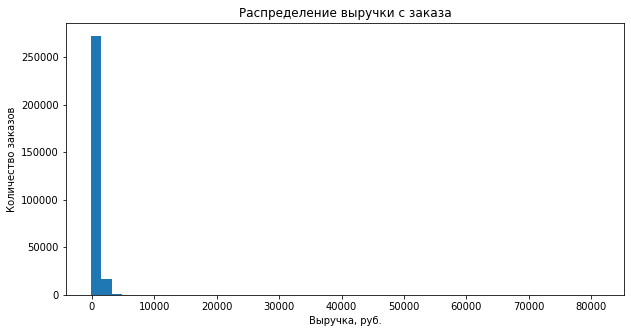

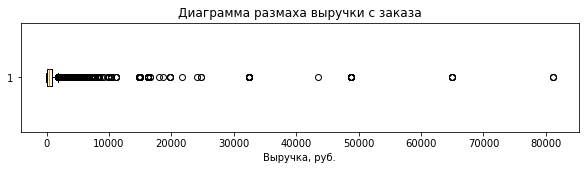

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(df['revenue_rub'], bins=50)
plt.title('Распределение выручки с заказа')
plt.xlabel('Выручка, руб.')
plt.ylabel('Количество заказов')
plt.show()

plt.figure(figsize=(10, 2))
plt.boxplot(df['revenue_rub'], vert=False)
plt.title('Диаграмма размаха выручки с заказа')
plt.xlabel('Выручка, руб.')
plt.show()

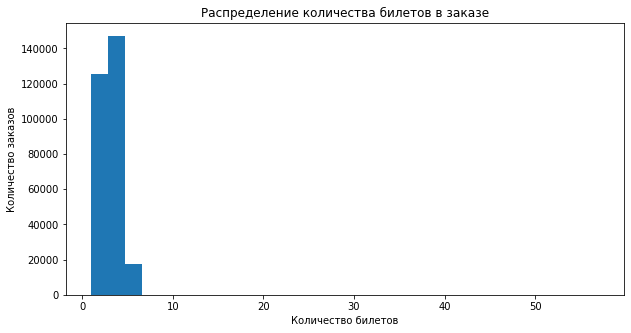

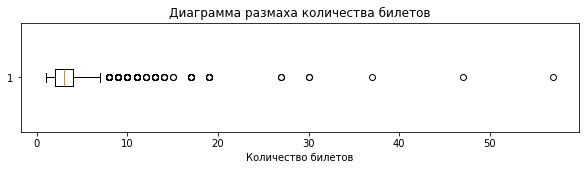

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(df['tickets_count'], bins=30)
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Количество заказов')
plt.show()

plt.figure(figsize=(10, 2))
plt.boxplot(df['tickets_count'], vert=False)
plt.title('Диаграмма размаха количества билетов')
plt.xlabel('Количество билетов')
plt.show()

По условию проекта выбросы в `revenue_rub` нужно отфильтровать по 99-му перцентилю. При этом важно не потерять историю заказов пользователя: дорогой заказ не должен исчезать из подсчёта количества заказов, даты первого заказа или интервала между покупками. Поэтому исходный `df` сохраню для поведенческих признаков, а для расчётов, связанных с выручкой, создам отдельную таблицу `df_revenue`.

In [20]:
rows_before = len(df)

revenue_99 = df['revenue_rub'].quantile(0.99)
print('99-й перцентиль revenue_rub:', revenue_99)

df_revenue = df[df['revenue_rub'] <= revenue_99].copy()

rows_after = len(df_revenue)
filtered_rows = rows_before - rows_after
filtered_share = filtered_rows / rows_before

print('Строк до фильтрации:', rows_before)
print('Строк после фильтрации:', rows_after)
print('Удалено строк:', filtered_rows)
print('Доля удалённых строк:', round(filtered_share, 4))

99-й перцентиль revenue_rub: 2628.4217390400004
Строк до фильтрации: 290611
Строк после фильтрации: 287786
Удалено строк: 2825
Доля удалённых строк: 0.0097


In [21]:
display(df_revenue[['revenue_rub', 'tickets_count']].describe())

,revenue_rub,tickets_count
count,287786.000000,287786.000000
mean,518.029224,2.740495
std,511.963780,1.163073
min,-90.760000,1.000000
25%,111.850000,2.000000
50%,343.850000,3.000000
75%,788.660000,3.000000
max,2628.421739,57.000000


### Промежуточный вывод по предобработке

В исходной выборке **285 542 заказа оплачены в рублях и 5 069 заказов в тенге**. Период таблицы курсов полностью покрывает период заказов, и для всех заказов в тенге курс был найден. После пересчёта создан единый показатель `revenue_rub`.

Пропуски обнаружены только в `days_since_prev`: **21 933 значения**, то есть по одному для первого заказа каждого пользователя. Это ожидаемо по смыслу показателя, поскольку для первого заказа предыдущего заказа ещё нет. В остальных исходных столбцах пропусков нет.

До фильтрации медианная выручка с заказа составляла **351,14 руб.**, средняя - **555,57 руб.**, а максимальная - **81 174,54 руб.** Распределение имеет длинный правый хвост. По условию проекта для дальнейшего анализа выручки значения выше 99-го перцентиля исключаются.

Граница 99-го перцентиля составила **2 628,42 руб.** Всего было исключено **2 825 заказов**, или около **0,97% исходной выборки**. 

После фильтрации осталось **287 786 заказов**. Средняя выручка снизилась до **518,03 руб.**, медианная составила **343,85 руб.**, а максимальная - **2 628,42 руб.** Таким образом, фильтрация позволила уменьшить влияние наиболее высоких значений выручки на дальнейший анализ, затронув менее 1% заказов.

При этом исходный `df` сохраняется без удаления заказов. Отфильтрованная таблица `df_revenue` используется только там, где рассчитываются показатели выручки. Такой подход позволяет не искажать количество заказов, признаки первого заказа и интервалы между покупками пользователя из-за фильтрации выбросов выручки.

Количество билетов в большинстве заказов небольшое: медиана равна **3**, 75% заказов содержат не более **3 билетов**, при максимальном значении **57**. Высокие значения встречаются редко, но на этом этапе они не удаляются, поскольку могут соответствовать реальным групповым покупкам.

В выручке также встречаются отрицательные и нулевые значения. В данных нет отдельного признака возврата или корректировки платежа, поэтому только по значению `revenue_rub` нельзя однозначно считать такие строки техническими ошибками. Они сохранены в данных.

<a id="user-profile"></a>
# 3. Формирование профиля пользователя

Теперь перейду от отдельных заказов к уровню пользователя.

Поведенческие признаки пользователя - первый и последний заказ, количество заказов, количество билетов и интервалы - рассчитаю по полной истории `df`. Среднюю выручку рассчитаю отдельно по `df_revenue`, где уже отфильтрованы выбросы выше 99-го перцентиля.

Перед построением профиля отсортирую данные по времени совершения заказа.

In [22]:
df = df.sort_values(['user_id', 'order_ts']).reset_index(drop=True)
df_revenue = df_revenue.sort_values(['user_id', 'order_ts']).reset_index(drop=True)

Сначала отдельно получу признаки первого заказа. Метод `drop_duplicates()` после сортировки оставит первую строку каждого пользователя.

In [23]:
first_orders = df.drop_duplicates(subset='user_id', keep='first')[
    [
        'user_id',
        'order_dt',
        'device_type_canonical',
        'region_name',
        'service_name',
        'event_type_main'
    ]
].copy()

first_orders = first_orders.rename(columns={
    'order_dt': 'first_order_dt',
    'device_type_canonical': 'first_device',
    'region_name': 'first_region',
    'service_name': 'first_service',
    'event_type_main': 'first_event_type'
})

display(first_orders.head())

,user_id,first_order_dt,first_device,first_region,first_service,first_event_type
0,0002849b70a3ce2,2024-08-20,mobile,Каменевский регион,Край билетов,театр
1,0005ca5e93f2cf4,2024-07-23,mobile,Каменевский регион,Мой билет,выставки
3,000898990054619,2024-07-13,mobile,Североярская область,Лови билет!,другое
6,00096d1f542ab2b,2024-08-15,desktop,Каменевский регион,Край билетов,театр
7,000a55a418c128c,2024-09-29,mobile,Поленовский край,Лучшие билеты,театр


Теперь рассчитаю поведенческие показатели по полной истории пользователя. Среднюю выручку посчитаю отдельно по данным после фильтрации выбросов и затем присоединю к профилю.

In [24]:
user_stats = df.groupby('user_id').agg(
    last_order_dt=('order_dt', 'max'),
    total_orders=('order_id', 'nunique'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_since_prev=('days_since_prev', 'mean')
).reset_index()

revenue_stats = df_revenue.groupby('user_id').agg(
    avg_revenue_rub=('revenue_rub', 'mean')
).reset_index()

user_stats = user_stats.merge(
    revenue_stats,
    on='user_id',
    how='left'
)

display(user_stats.head())

,user_id,last_order_dt,total_orders,avg_tickets_count,avg_days_since_prev,avg_revenue_rub
0,0002849b70a3ce2,2024-08-20,1,4.000000,<NA>,1521.940000
1,0005ca5e93f2cf4,2024-10-06,2,3.000000,75.0,774.010000
2,000898990054619,2024-10-23,3,2.666667,51.0,767.213333
3,00096d1f542ab2b,2024-08-15,1,4.000000,<NA>,917.830000
4,000a55a418c128c,2024-10-15,2,1.500000,16.0,61.310000


In [25]:
user_profile = first_orders.merge(
    user_stats,
    on='user_id',
    how='left'
)

user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

display(user_profile.head())

,user_id,first_order_dt,first_device,first_region,first_service,first_event_type,last_order_dt,total_orders,avg_tickets_count,avg_days_since_prev,avg_revenue_rub,is_two,is_five
0,0002849b70a3ce2,2024-08-20,mobile,Каменевский регион,Край билетов,театр,2024-08-20,1,4.000000,<NA>,1521.940000,0,0
1,0005ca5e93f2cf4,2024-07-23,mobile,Каменевский регион,Мой билет,выставки,2024-10-06,2,3.000000,75.0,774.010000,1,0
2,000898990054619,2024-07-13,mobile,Североярская область,Лови билет!,другое,2024-10-23,3,2.666667,51.0,767.213333,1,0
3,00096d1f542ab2b,2024-08-15,desktop,Каменевский регион,Край билетов,театр,2024-08-15,1,4.000000,<NA>,917.830000,0,0
4,000a55a418c128c,2024-09-29,mobile,Поленовский край,Лучшие билеты,театр,2024-10-15,2,1.500000,16.0,61.310000,1,0


### 3.1. Общая характеристика профилей

Рассчитаю основные показатели выборки. Среднее значение бинарного признака удобно интерпретировать как долю пользователей, для которых условие выполняется.

In [26]:
print('Количество пользователей:', user_profile['user_id'].nunique())
print('Средняя выручка с заказа после фильтрации выбросов:', round(df_revenue['revenue_rub'].mean(), 2))
print('Доля пользователей с 2+ заказами:', round(user_profile['is_two'].mean(), 4))
print('Доля пользователей с 5+ заказами:', round(user_profile['is_five'].mean(), 4))
print('Пользователей без avg_revenue_rub после фильтрации:', user_profile['avg_revenue_rub'].isna().sum())

Количество пользователей: 21933
Средняя выручка с заказа после фильтрации выбросов: 518.03
Доля пользователей с 2+ заказами: 0.6182
Доля пользователей с 5+ заказами: 0.2918
Пользователей без avg_revenue_rub после фильтрации: 79


In [27]:
display(
    user_profile[
        ['total_orders', 'avg_tickets_count', 'avg_days_since_prev']
    ].describe()
)

,total_orders,avg_tickets_count,avg_days_since_prev
count,21933.000000,21933.000000,13559.0
mean,13.249943,2.755987,15.808537
std,122.470535,0.920739,22.249582
min,1.000000,1.000000,0.0
25%,1.000000,2.000000,1.0
50%,2.000000,2.764151,8.0
75%,5.000000,3.125000,20.4
max,10251.000000,12.000000,148.0


Дополнительно посмотрю распределения. Для `avg_days_since_prev` значения есть только у пользователей, которые совершали повторные покупки.

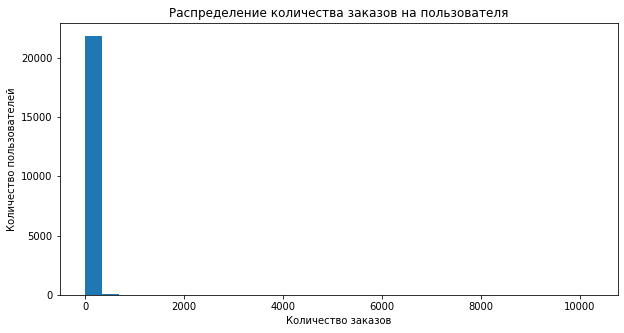

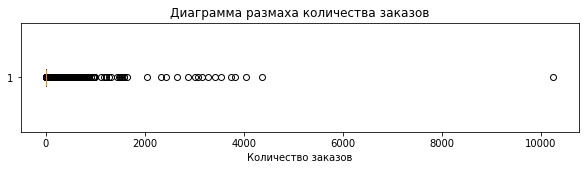

In [28]:
plt.figure(figsize=(10, 5))
plt.hist(user_profile['total_orders'], bins=30)
plt.title('Распределение количества заказов на пользователя')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')
plt.show()

plt.figure(figsize=(10, 2))
plt.boxplot(user_profile['total_orders'], vert=False)
plt.title('Диаграмма размаха количества заказов')
plt.xlabel('Количество заказов')
plt.show()

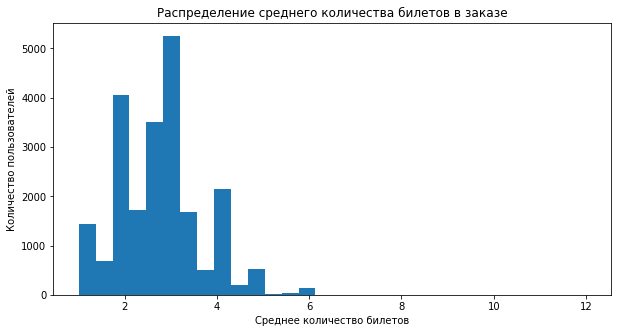

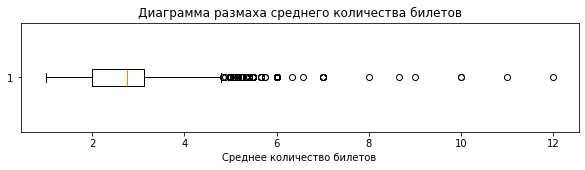

In [29]:
plt.figure(figsize=(10, 5))
plt.hist(user_profile['avg_tickets_count'], bins=30)
plt.title('Распределение среднего количества билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')
plt.show()

plt.figure(figsize=(10, 2))
plt.boxplot(user_profile['avg_tickets_count'], vert=False)
plt.title('Диаграмма размаха среднего количества билетов')
plt.xlabel('Среднее количество билетов')
plt.show()

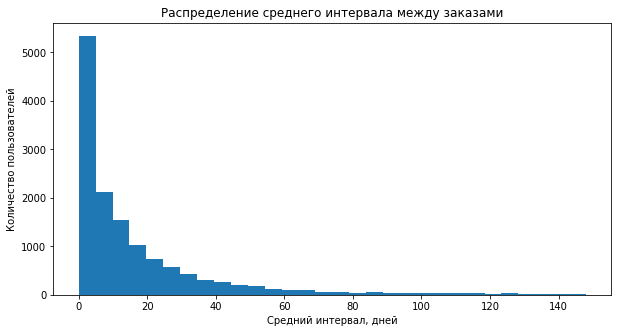

In [30]:
repeat_users = user_profile[user_profile['avg_days_since_prev'].notna()]

plt.figure(figsize=(10, 5))
plt.hist(repeat_users['avg_days_since_prev'], bins=30)
plt.title('Распределение среднего интервала между заказами')
plt.xlabel('Средний интервал, дней')
plt.ylabel('Количество пользователей')
plt.show()

Если на графиках будут заметны аномально большие значения, ниже можно проверить 95-й и 99-й перцентили. Решение о дополнительной фильтрации приму только после просмотра фактического распределения.

In [31]:
for column in ['total_orders', 'avg_tickets_count']:
    print('\nСтолбец:', column)
    print('95-й перцентиль:', user_profile[column].quantile(0.95))
    print('99-й перцентиль:', user_profile[column].quantile(0.99))
    print('Максимум:', user_profile[column].max())


Столбец: total_orders
95-й перцентиль: 32.0
99-й перцентиль: 152.0
Максимум: 10251

Столбец: avg_tickets_count
95-й перцентиль: 4.0
99-й перцентиль: 5.0
Максимум: 12.0


### Промежуточный вывод по профилю пользователя

После построения профиля в выборке осталось **21 933 пользователя**, то есть фильтрация выбросов выручки не удаляет пользователей и не меняет историю их заказов. Объём выборки достаточен для дальнейшего исследовательского анализа, однако при анализе отдельных малочисленных сегментов необходимо учитывать их размер.

Средняя выручка с одного заказа после фильтрации выбросов составляет **518,03 руб.** Два и более заказа совершили **61,8% пользователей**, а пять и более - **29,2%**.

Медианное количество заказов на пользователя равно **2**, а 75% пользователей сделали не более **5 заказов**. При этом распределение количества заказов сильно скошено вправо: среднее составляет **13,25 заказа**, 99-й перцентиль - **152 заказа**, а максимальное значение достигает **10 251 заказа**. Это аномально высокие значения относительно основной части выборки, однако удалять таких пользователей только из-за высокой активности не буду: частота покупок является одним из основных показателей проекта, а признаков технической ошибки в данных нет. Поэтому эти наблюдения сохраняются и будут учитываться при анализе с использованием медиан и групп по количеству заказов.

Среднее количество билетов в заказе значительно стабильнее: медиана составляет около **2,76 билета**, 99-й перцентиль - **5**, максимум - **12**. Высокие значения встречаются редко и могут соответствовать реальным групповым покупкам, поэтому дополнительная фильтрация по этому показателю не требуется.

У пользователей с повторными заказами медианный средний интервал между покупками составляет **8 дней**, средний - около **15,8 дня**. Разница между средним и медианой указывает на наличие пользователей с более длинными интервалами между покупками.

У **79 пользователей** после фильтрации выбросов выручки не осталось значений для расчёта `avg_revenue_rub`. При этом они сохранены в пользовательском профиле, чтобы фильтрация выручки не изменяла количество заказов и другие характеристики поведения пользователей.

Таким образом, основные аномалии связаны с очень большим количеством заказов у небольшой части пользователей. Эти наблюдения решено **не удалять**, поскольку высокая покупательская активность непосредственно относится к предмету исследования и нет оснований считать такие значения ошибочными. Дополнительная фильтрация пользовательского профиля не проводится, поэтому пересчёт статистических показателей после фильтрации на этом этапе не требуется.

<a id="eda"></a>
# 4. Исследовательский анализ данных

Основная задача этого раздела - сравнить пользователей, которые вернулись за повторной покупкой, с пользователями, которые совершили только один заказ.

## 4.1. Признаки первого заказа и возврат пользователей

### 4.1.1. Распределение пользователей по сегментам

Для каждого признака первого заказа рассчитаю число пользователей и их долю.

In [32]:
segment_columns = [
    'first_event_type',
    'first_device',
    'first_region',
    'first_service'
]

for column in segment_columns:
    segment = user_profile.groupby(column).agg(
        users=('user_id', 'count')
    ).reset_index()

    segment['share'] = segment['users'] / segment['users'].sum()
    segment = segment.sort_values('users', ascending=False)

    print('\nПризнак:', column)
    display(segment.head(20))


Признак: first_event_type


,first_event_type,users,share
2,концерты,9701,0.442302
1,другое,5489,0.250262
5,театр,4312,0.196599
4,стендап,1118,0.050973
3,спорт,804,0.036657
0,выставки,414,0.018876
6,ёлки,95,0.004331



Признак: first_device


,first_device,users,share
1,mobile,18161,0.828022
0,desktop,3772,0.171978



Признак: first_region


,first_region,users,share
23,Каменевский регион,7209,0.328683
60,Североярская область,3795,0.173027
77,Широковская область,1244,0.056718
45,Озернинский край,679,0.030958
41,Малиновоярский округ,536,0.024438
76,Шанырский регион,509,0.023207
74,Травяная область,494,0.022523
57,Светополянский округ,469,0.021383
52,Речиновская область,442,0.020152
78,Яблоневская область,419,0.019104



Признак: first_service


,first_service,users,share
3,Билеты без проблем,5233,0.238590
22,Мой билет,3022,0.137783
19,Лови билет!,2853,0.130078
4,Билеты в руки,2587,0.117950
23,Облачко,2195,0.100078
7,Весь в билетах,1320,0.060183
20,Лучшие билеты,1186,0.054074
24,Прачечная,592,0.026991
17,Край билетов,462,0.021064
12,Дом культуры,355,0.016186


**Промежуточный вывод**

Распределение пользователей по признакам первого заказа неравномерное.

Главная точка входа по типу мероприятия - **концерты**: с них начали 44,2% пользователей. Далее идут категория «другое» - 25,0% и театр - 19,7%.

По устройству особенно заметно преобладание mobile: **82,8%** пользователей совершили первый заказ с мобильного устройства и 17,2% - с desktop.

Среди регионов крупнейшим является **Каменевский регион** - 32,9% пользователей, затем Североярская область - 17,3%. Среди билетных операторов крупнейшая точка входа - **«Билеты без проблем»** с долей 23,9%.

Таким образом, выраженные точки входа есть по всем рассматриваемым признакам, особенно по устройству, типу мероприятия и крупнейшим регионам.

### 4.1.2. Доля вернувшихся пользователей в сегментах

Так как `is_two` принимает значения 0 и 1, его среднее значение внутри сегмента равно доле пользователей с двумя и более заказами.

In [33]:
def segment_return_table(data, column):
    result = data.groupby(column).agg(
        users=('user_id', 'count'),
        return_share=('is_two', 'mean')
    ).reset_index()

    result = result.sort_values('users', ascending=False)
    return result

In [34]:
event_return = segment_return_table(user_profile, 'first_event_type')
device_return = segment_return_table(user_profile, 'first_device')
region_return = segment_return_table(user_profile, 'first_region')
service_return = segment_return_table(user_profile, 'first_service')

display(event_return)
display(device_return)
display(region_return.head(10))
display(service_return.head(10))

,first_event_type,users,return_share
2,концерты,9701,0.623956
1,другое,5489,0.601202
5,театр,4312,0.638915
4,стендап,1118,0.610018
3,спорт,804,0.562189
0,выставки,414,0.640097
6,ёлки,95,0.547368


,first_device,users,return_share
1,mobile,18161,0.613182
0,desktop,3772,0.642365


,first_region,users,return_share
23,Каменевский регион,7209,0.628520
60,Североярская область,3795,0.642424
77,Широковская область,1244,0.651125
45,Озернинский край,679,0.552283
41,Малиновоярский округ,536,0.565299
76,Шанырский регион,509,0.685658
74,Травяная область,494,0.619433
57,Светополянский округ,469,0.663113
52,Речиновская область,442,0.640271
78,Яблоневская область,419,0.599045


,first_service,users,return_share
3,Билеты без проблем,5233,0.608064
22,Мой билет,3022,0.613832
19,Лови билет!,2853,0.616193
4,Билеты в руки,2587,0.632006
23,Облачко,2195,0.616856
7,Весь в билетах,1320,0.636364
20,Лучшие билеты,1186,0.613828
24,Прачечная,592,0.630068
17,Край билетов,462,0.655844
12,Дом культуры,355,0.647887


In [35]:
overall_return_share = user_profile['is_two'].mean()
print('Средняя доля возврата по выборке:', round(overall_return_share, 4))

Средняя доля возврата по выборке: 0.6182


Для региона и билетного оператора категорий может быть много, поэтому на графиках покажу только 10 крупнейших сегментов по числу пользователей.

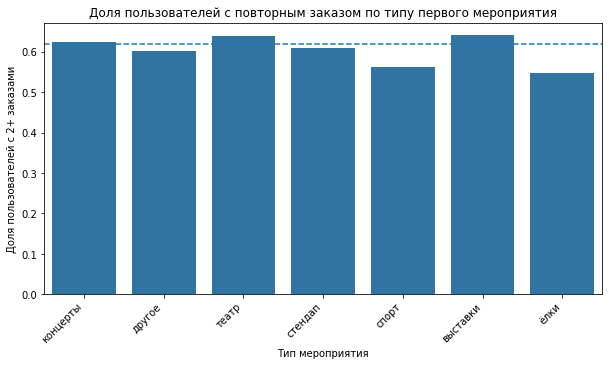

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(data=event_return, x='first_event_type', y='return_share')
plt.axhline(overall_return_share, linestyle='--')
plt.title('Доля пользователей с повторным заказом по типу первого мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=45, ha='right')
plt.show()

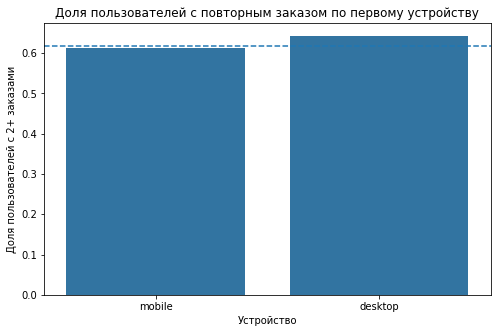

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(data=device_return, x='first_device', y='return_share')
plt.axhline(overall_return_share, linestyle='--')
plt.title('Доля пользователей с повторным заказом по первому устройству')
plt.xlabel('Устройство')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.show()

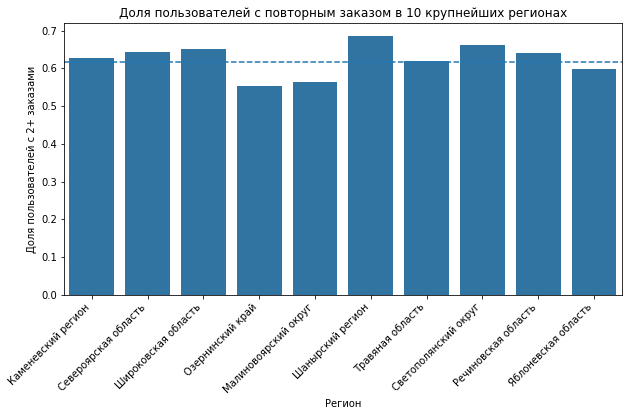

In [38]:
region_top10 = region_return.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=region_top10, x='first_region', y='return_share')
plt.axhline(overall_return_share, linestyle='--')
plt.title('Доля пользователей с повторным заказом в 10 крупнейших регионах')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=45, ha='right')
plt.show()

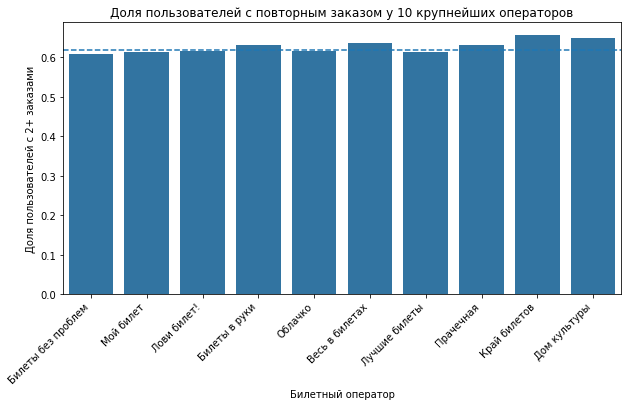

In [39]:
service_top10 = service_return.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=service_top10, x='first_service', y='return_share')
plt.axhline(overall_return_share, linestyle='--')
plt.title('Доля пользователей с повторным заказом у 10 крупнейших операторов')
plt.xlabel('Билетный оператор')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=45, ha='right')
plt.show()

**Промежуточный вывод**

Средняя доля пользователей с повторным заказом по всей выборке составляет **61,8%**.

Среди крупных типов мероприятий наиболее высокая доля возврата наблюдается у театра - около **63,9%**, для концертов она составляет 62,4%, для стендапа - 61,0%, а для спорта - 56,2%. У выставок показатель немного выше - 64,0%, но этот сегмент значительно меньше и включает 414 пользователей.

Пользователи, впервые сделавшие заказ с desktop, возвращались несколько чаще: **64,2% против 61,3%** у mobile. При этом mobile является намного более крупной точкой входа.

Среди десяти крупнейших регионов и билетных операторов также есть различия в доле возврата. Например, среди крупных регионов показатель меняется примерно от 55% до 69%. Поэтому при интерпретации важно учитывать одновременно и долю возврата, и размер сегмента.

### 4.1.3. Проверка продуктовых гипотез

#### Гипотеза 1
Пользователи, чей первый заказ был на спортивное мероприятие, совершают повторный заказ чаще пользователей, чей первый заказ был на концерт.

Сначала посмотрю фактические названия категорий, чтобы сравнивать именно те значения, которые присутствуют в данных.

In [40]:
display(
    user_profile['first_event_type']
    .value_counts()
    .rename_axis('event_type')
    .reset_index(name='users')
)

,event_type,users
0,концерты,9701
1,другое,5489
2,театр,4312
3,стендап,1118
4,спорт,804
5,выставки,414
6,ёлки,95


После просмотра таблицы ниже нужно указать точные названия спортивной категории и концертов, если они отличаются от формулировок задания.

In [41]:
hypothesis_1 = event_return[
    event_return['first_event_type'].isin(['спорт', 'концерты'])
]

display(hypothesis_1)

,first_event_type,users,return_share
2,концерты,9701,0.623956
3,спорт,804,0.562189


**Вывод по гипотезе 1**

Гипотеза **не подтверждается на текущей выборке**. Среди пользователей, чей первый заказ был на спортивное мероприятие, повторный заказ сделали около **56,2%**, а среди пользователей, впервые купивших билет на концерт, - около **62,4%**.

Концертный сегмент также значительно крупнее: 9 701 пользователь против 804 пользователей в спортивном сегменте.

Таким образом, в исследуемых данных пользователи после первого заказа на спорт возвращались не чаще, а реже пользователей после первого заказа на концерт. Это наблюдаемая связь, а не доказательство причинного влияния типа мероприятия.

#### Гипотеза 2
В регионах с наибольшим количеством пользователей доля повторных заказов выше, чем в менее активных регионах.

Для проверки сопоставлю размер каждого регионального сегмента с долей пользователей, которые совершили повторный заказ.

,first_region,users,return_share
23,Каменевский регион,7209,0.628520
60,Североярская область,3795,0.642424
77,Широковская область,1244,0.651125
45,Озернинский край,679,0.552283
41,Малиновоярский округ,536,0.565299
...,...,...,...
17,Залесский край,2,0.500000
70,Тихогорская область,2,0.500000
5,Верхозёрский край,1,1.000000
66,Сосноводолинская область,1,0.000000


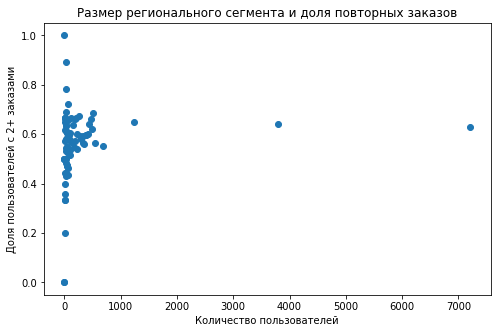

In [42]:
region_hypothesis = region_return.sort_values('users', ascending=False)

display(region_hypothesis)

plt.figure(figsize=(8, 5))
plt.scatter(region_hypothesis['users'], region_hypothesis['return_share'])
plt.title('Размер регионального сегмента и доля повторных заказов')
plt.xlabel('Количество пользователей')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.show()

**Вывод по гипотезе 2**

Однозначной зависимости «чем больше пользователей в регионе, тем выше доля повторных заказов» не наблюдается.

Три крупнейших региона действительно показывают долю возврата около или выше среднего уровня: Каменевский регион - 62,9%, Североярская область - 64,2%, Широковская область - 65,1%. Однако среди следующих крупных регионов встречаются как более низкие значения, например 55,2% в Озернинском крае, так и более высокие - 68,6% в Шанырском регионе.

Следовательно, размер регионального сегмента сам по себе не определяет долю повторных заказов. Гипотеза в исходной формулировке **не получает устойчивого подтверждения**.

## 4.2. Выручка и состав заказа

### 4.2.1. Средняя выручка и повторные заказы

Сравню распределение средней выручки с заказа для пользователей с одним заказом и пользователей с двумя и более заказами.

Использую одинаковое количество интервалов, прозрачность и `density=True`, чтобы сравнивать именно форму распределений, несмотря на разный размер групп.

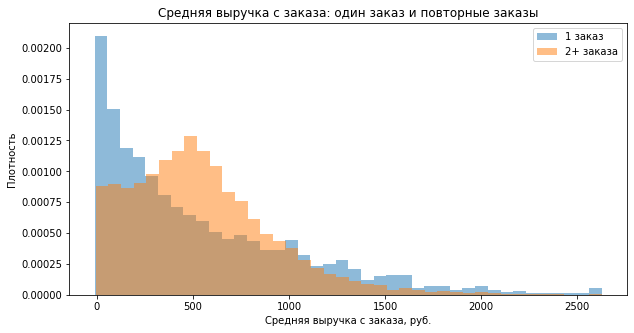

In [43]:
one_order = user_profile[user_profile['total_orders'] == 1]
two_plus = user_profile[user_profile['total_orders'] >= 2]

plt.figure(figsize=(10, 5))
plt.hist(
    one_order['avg_revenue_rub'],
    bins=40,
    alpha=0.5,
    density=True,
    label='1 заказ'
)
plt.hist(
    two_plus['avg_revenue_rub'],
    bins=40,
    alpha=0.5,
    density=True,
    label='2+ заказа'
)

plt.title('Средняя выручка с заказа: один заказ и повторные заказы')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.show()

In [44]:
display(
    user_profile.groupby('is_two')['avg_revenue_rub'].describe()
)

,count,mean,std,min,25%,50%,75%,max
is_two,,,,,,,,
0,8313.0,541.389184,514.795967,-10.770,131.540,375.150,823.93,2628.421739
1,13541.0,546.245234,371.439037,-5.385,274.338,498.085,740.98,2628.421739


**Промежуточный вывод**

Средняя выручка с заказа почти не различается между пользователями с одним заказом и пользователями с повторными заказами: около **541,4 руб. против 546,2 руб.**

Медианы различаются заметнее: около **375 руб.** у пользователей с одним заказом и **498,1 руб.** у пользователей с 2+ заказами. При этом разброс у пользователей с одним заказом выше.

Таким образом, по среднему значению сильного различия между группами не видно, хотя форма распределений и медианные значения отличаются. Поэтому нельзя утверждать, что более высокая средняя выручка сама по себе означает более высокую вероятность возврата.

### 4.2.2. Пользователи с 2-4 заказами и 5+ заказами

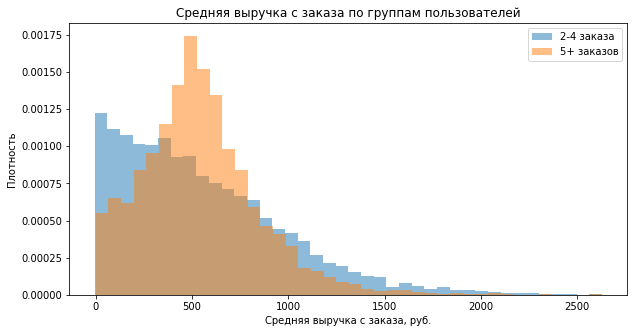

In [45]:
orders_2_4 = user_profile[
    (user_profile['total_orders'] >= 2)
    & (user_profile['total_orders'] <= 4)
]

orders_5_plus = user_profile[
    user_profile['total_orders'] >= 5
]

plt.figure(figsize=(10, 5))
plt.hist(
    orders_2_4['avg_revenue_rub'],
    bins=40,
    alpha=0.5,
    density=True,
    label='2-4 заказа'
)
plt.hist(
    orders_5_plus['avg_revenue_rub'],
    bins=40,
    alpha=0.5,
    density=True,
    label='5+ заказов'
)

plt.title('Средняя выручка с заказа по группам пользователей')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.show()

In [46]:
print('2-4 заказа:')
display(orders_2_4['avg_revenue_rub'].describe())

print('5+ заказов:')
display(orders_5_plus['avg_revenue_rub'].describe())

2-4 заказа:


count    7141.000000
mean      551.518837
std       423.369143
min        -5.385000
25%       217.503333
50%       470.150000
75%       797.375000
max      2628.421739
Name: avg_revenue_rub, dtype: float64

5+ заказов:


count    6400.000000
mean      540.361047
std       303.098703
min         0.000000
25%       339.100869
50%       515.168313
75%       696.574699
max      2628.421739
Name: avg_revenue_rub, dtype: float64

**Промежуточный вывод**

У пользователей с 2-4 заказами средняя выручка с заказа составляет около **551,5 руб.**, а у пользователей с 5+ заказами - около **540,4 руб.** Медианы равны примерно **470,2 и 515,2 руб.** соответственно.

Различия между группами небольшие и не показывают, что наиболее активные пользователи обязательно совершают более дорогие заказы. При этом у группы 5+ заказов разброс средней выручки меньше.

### 4.2.3. Среднее количество билетов и повторные покупки

Сначала посмотрю распределение среднего количества билетов, а затем разделю пользователей на интервалы из задания.

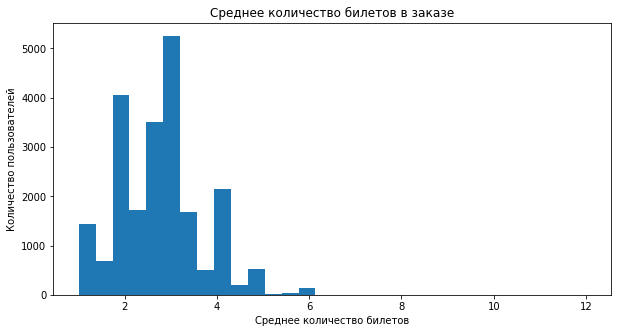

In [47]:
plt.figure(figsize=(10, 5))
plt.hist(user_profile['avg_tickets_count'], bins=30)
plt.title('Среднее количество билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')
plt.show()

Границы сегментов в условии соприкасаются в точках 2, 3 и 5. Чтобы один пользователь не оказался сразу в двух группах, использую интервалы:
- от 1 включительно до 2 включительно;
- больше 2 до 3 включительно;
- больше 3 до 5 включительно;
- больше 5.

Так каждый пользователь попадёт только в один сегмент.

In [48]:
user_profile['tickets_segment'] = pd.cut(
    user_profile['avg_tickets_count'],
    bins=[0, 2, 3, 5, float('inf')],
    labels=['1-2', '2-3', '3-5', '5+'],
    include_lowest=True
)

tickets_segments = user_profile.groupby(
    'tickets_segment',
    observed=True
).agg(
    users=('user_id', 'count'),
    return_share=('is_two', 'mean')
).reset_index()

display(tickets_segments)

,tickets_segment,users,return_share
0,1-2,6120,0.400490
1,2-3,10091,0.747498
2,3-5,5513,0.634319
3,5+,209,0.325359


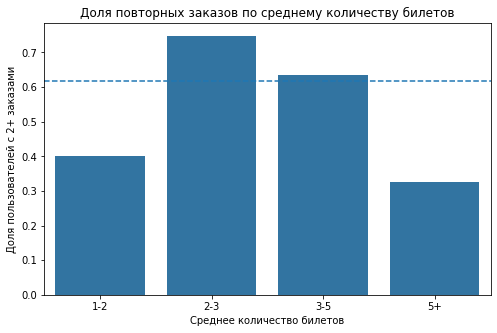

In [49]:
plt.figure(figsize=(8, 5))
sns.barplot(data=tickets_segments, x='tickets_segment', y='return_share')
plt.axhline(overall_return_share, linestyle='--')
plt.title('Доля повторных заказов по среднему количеству билетов')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.show()

**Промежуточный вывод**

Пользователи распределены по сегментам среднего количества билетов неравномерно. Самый крупный сегмент - **от 2 до 3 билетов**, в нём 10 091 пользователь.

В этом сегменте наблюдается и самая высокая доля повторных заказов - около **74,7%**. Для пользователей со средним количеством от 3 до 5 билетов доля составляет около 63,4%, а в сегменте 1-2 билета - около 40,0%.

У пользователей со средним количеством более 5 билетов доля возврата ниже - около 32,5%, однако этот сегмент очень мал: всего 209 пользователей. Поэтому его результат менее устойчив.

В целом зависимость не является линейной: рост среднего количества билетов не сопровождается постоянным ростом доли повторных покупок.

## 4.3. Временные характеристики

### 4.3.1. День недели первой покупки

Из даты первого заказа выделю день недели и сравню долю возврата.

In [50]:
user_profile['first_weekday_num'] = user_profile['first_order_dt'].dt.dayofweek

weekday_names = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}

user_profile['first_weekday'] = user_profile['first_weekday_num'].map(weekday_names)

weekday_return = user_profile.groupby(
    ['first_weekday_num', 'first_weekday']
).agg(
    users=('user_id', 'count'),
    return_share=('is_two', 'mean')
).reset_index()

weekday_return = weekday_return.sort_values('first_weekday_num')

display(weekday_return)

,first_weekday_num,first_weekday,users,return_share
0,0,Понедельник,2947,0.633865
1,1,Вторник,3218,0.624612
2,2,Среда,3084,0.624838
3,3,Четверг,3130,0.595847
4,4,Пятница,3274,0.599267
5,5,Суббота,3461,0.641144
6,6,Воскресенье,2819,0.605889


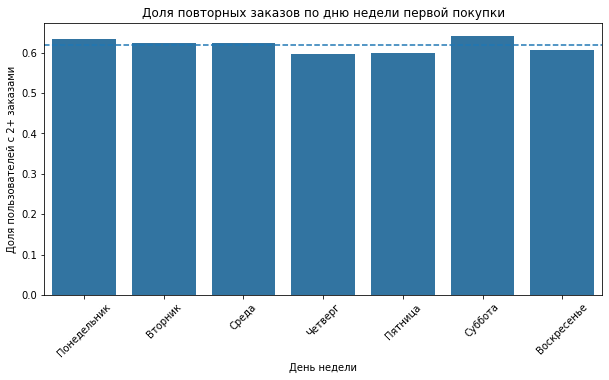

In [51]:
plt.figure(figsize=(10, 5))
sns.barplot(data=weekday_return, x='first_weekday', y='return_share')
plt.axhline(overall_return_share, linestyle='--')
plt.title('Доля повторных заказов по дню недели первой покупки')
plt.xlabel('День недели')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=45)
plt.show()

**Промежуточный вывод**

Доля повторных заказов по дням недели первой покупки находится примерно в диапазоне **59,6-64,1%**.

Самая высокая доля наблюдается у пользователей, впервые купивших билет в субботу - около 64,1%, а самая низкая - в четверг, около 59,6%. В понедельник показатель также немного выше среднего - 63,4%.

Различия между днями есть, но они сравнительно небольшие. Поэтому день недели первого заказа не выглядит сильным признаком возврата пользователей.

### 4.3.2. Средний интервал между заказами

Сравню среднее время между покупками у пользователей с 2-4 заказами и у пользователей с 5 и более заказами.

In [52]:
interval_comparison = user_profile[
    user_profile['total_orders'] >= 2
].copy()

interval_comparison['orders_group'] = '2-4 заказа'

interval_comparison.loc[
    interval_comparison['total_orders'] >= 5,
    'orders_group'
] = '5+ заказов'

display(
    interval_comparison.groupby('orders_group')['avg_days_since_prev'].describe()
)

,count,mean,std,min,25%,50%,75%,max
orders_group,,,,,,,,
2-4 заказа,7159.0,21.326326,28.589919,0.0,0.0,9.0,34.0,148.0
5+ заказов,6400.0,9.636372,7.898397,0.0,3.427198,7.833333,13.891667,37.5


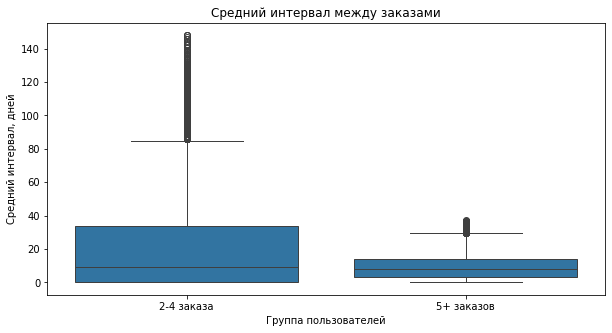

In [53]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=interval_comparison,
    x='orders_group',
    y='avg_days_since_prev'
)
plt.title('Средний интервал между заказами')
plt.xlabel('Группа пользователей')
plt.ylabel('Средний интервал, дней')
plt.show()

**Промежуточный вывод**

У пользователей с 2-4 заказами средний интервал между покупками составляет около **21,3 дня**, медианный - **9 дней**. У пользователей с 5+ заказами интервалы заметно короче: среднее около **9,6 дня**, медиана - около **7,8 дня**.

Таким образом, наиболее активные пользователи совершают покупки чаще.

При этом `avg_days_since_prev` рассчитывается по всей истории заказов пользователя. Поэтому этот показатель хорошо описывает уже сформировавшееся поведение постоянных клиентов, но его нельзя использовать как характеристику, известную сразу после первого заказа.

## 4.4. Корреляционный анализ Phi_K

Phi_K подходит для анализа связей между числовыми и категориальными признаками. Посмотрю, какие характеристики профиля пользователя связаны с количеством заказов.

Сначала импортирую библиотеку. Если в окружении она отсутствует, её можно установить командой `!pip install phik`.

In [54]:
import phik

Для анализа не нужны идентификатор пользователя, даты и технические признаки, которые были созданы только для построения отдельных графиков. Оставлю основные характеристики профиля.

In [55]:
phik_columns = [
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_since_prev',
    'total_orders'
]

phik_data = user_profile[phik_columns].copy()

phik_matrix = phik_data.phik_matrix(
    interval_cols=[
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_since_prev',
        'total_orders'
    ]
)

display(phik_matrix)

,first_device,first_region,first_service,first_event_type,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,total_orders
first_device,1.000000,0.116179,0.082762,0.061683,0.074189,0.057743,0.017841,0.000000
first_region,0.116179,1.000000,0.695739,0.510329,0.361698,0.111919,0.078989,0.127480
first_service,0.082762,0.695739,1.000000,0.587132,0.376523,0.154544,0.049938,0.103566
first_event_type,0.061683,0.510329,0.587132,1.000000,0.326187,0.081993,0.050810,0.000000
avg_revenue_rub,0.074189,0.361698,0.376523,0.326187,1.000000,0.423135,0.094389,0.000000
avg_tickets_count,0.057743,0.111919,0.154544,0.081993,0.423135,1.000000,0.086938,0.000000
avg_days_since_prev,0.017841,0.078989,0.049938,0.050810,0.094389,0.086938,1.000000,0.000000
total_orders,0.000000,0.127480,0.103566,0.000000,0.000000,0.000000,0.000000,1.000000


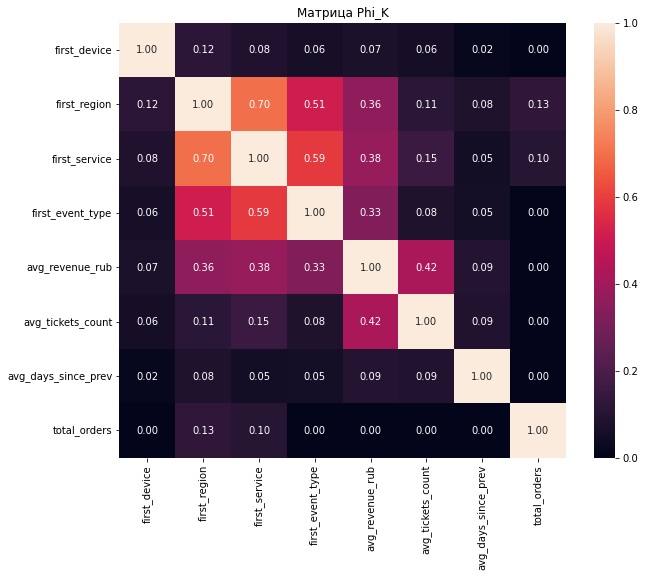

In [56]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    phik_matrix,
    annot=True,
    fmt='.2f'
)
plt.title('Матрица Phi_K')
plt.show()

In [57]:
display(
    phik_matrix[['total_orders']]
    .sort_values('total_orders', ascending=False)
)

,total_orders
total_orders,1.000000
first_region,0.127480
first_service,0.103566
first_device,0.000000
first_event_type,0.000000
avg_revenue_rub,0.000000
avg_tickets_count,0.000000
avg_days_since_prev,0.000000


Если почти все связи с `total_orders` окажутся близки к нулю, это может быть связано с тем, что в данных преобладают пользователи с одним заказом. В таком случае по заданию нужно объединить количество заказов в три группы и повторить анализ.

In [58]:
user_profile['orders_segment'] = '1 заказ'

user_profile.loc[
    (user_profile['total_orders'] >= 2)
    & (user_profile['total_orders'] <= 4),
    'orders_segment'
] = '2-4 заказа'

user_profile.loc[
    user_profile['total_orders'] >= 5,
    'orders_segment'
] = '5+ заказов'

print(user_profile['orders_segment'].value_counts())

1 заказ       8374
2-4 заказа    7159
5+ заказов    6400
Name: orders_segment, dtype: int64


In [59]:
phik_segment_columns = [
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_since_prev',
    'orders_segment'
]

phik_segment_data = user_profile[phik_segment_columns].copy()

phik_segment_matrix = phik_segment_data.phik_matrix(
    interval_cols=[
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_since_prev'
    ]
)

display(phik_segment_matrix)

,first_device,first_region,first_service,first_event_type,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,orders_segment
first_device,1.000000,0.116179,0.082762,0.061683,0.074189,0.057743,0.017841,0.016681
first_region,0.116179,1.000000,0.695739,0.510329,0.361698,0.111919,0.078989,0.125771
first_service,0.082762,0.695739,1.000000,0.587132,0.376523,0.154544,0.049938,0.081366
first_event_type,0.061683,0.510329,0.587132,1.000000,0.326187,0.081993,0.050810,0.041346
avg_revenue_rub,0.074189,0.361698,0.376523,0.326187,1.000000,0.423135,0.094389,0.329113
avg_tickets_count,0.057743,0.111919,0.154544,0.081993,0.423135,1.000000,0.086938,0.411519
avg_days_since_prev,0.017841,0.078989,0.049938,0.050810,0.094389,0.086938,1.000000,0.470375
orders_segment,0.016681,0.125771,0.081366,0.041346,0.329113,0.411519,0.470375,1.000000


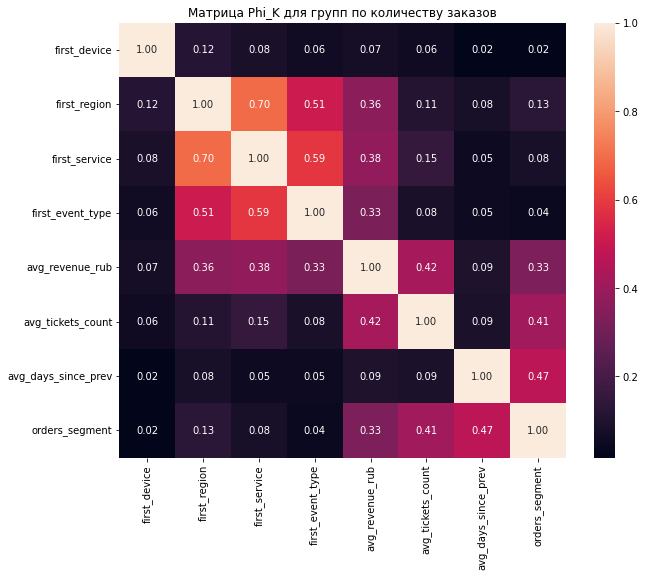

In [60]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    phik_segment_matrix,
    annot=True,
    fmt='.2f'
)
plt.title('Матрица Phi_K для групп по количеству заказов')
plt.show()

In [61]:
display(
    phik_segment_matrix[['orders_segment']]
    .sort_values('orders_segment', ascending=False)
)

,orders_segment
orders_segment,1.000000
avg_days_since_prev,0.470375
avg_tickets_count,0.411519
avg_revenue_rub,0.329113
first_region,0.125771
first_service,0.081366
first_event_type,0.041346
first_device,0.016681


### Промежуточный вывод по корреляционному анализу

При использовании исходного `total_orders` большинство значений Phi_K оказались близкими к нулю. Это связано с сильной неравномерностью распределения количества заказов: медиана равна 2, тогда как максимальное значение превышает 10 тысяч.

После объединения пользователей в группы `1 заказ`, `2-4 заказа` и `5+ заказов` связи стали заметнее. Наиболее высокие значения Phi_K с группой количества заказов получили:

- `avg_days_since_prev` - **0,47**;
- `avg_tickets_count` - **0,41**;
- `avg_revenue_rub` - **0,33**;
- `first_region` - **0,13**.

Связь с билетным оператором слабая - около 0,08, с типом первого мероприятия - около 0,04, а с устройством первого заказа - около 0,02.

Важно учитывать, что Phi_K показывает статистическую связь, но не доказывает причинность. Кроме того, средний интервал между заказами, средняя выручка и среднее количество билетов рассчитаны по всей истории пользователя. Эти признаки хорошо описывают уже сложившееся поведение, но не являются полностью доступными в момент первого заказа.

<a id="conclusion"></a>
# 5. Общие выводы и рекомендации

## Данные и предобработка

Для исследования использовались данные о заказах Яндекс Афиши за период с **1 июня по 31 октября 2024 года**. Исходная выборка содержала **290 611 заказов и 21 933 пользователя**. Полных дубликатов не обнаружено. Пропуски присутствовали только в `days_since_prev`, что ожидаемо для первого заказа пользователя.

В данных использовались рубли и казахстанские тенге. Для 5 069 заказов в тенге выручка была пересчитана в рубли по курсу на дату заказа. Для всех заказов в тенге курс был найден.

Распределение выручки имело длинный правый хвост. По условию проекта значения выше 99-го перцентиля, **2 628,42 руб.**, были исключены из расчётов выручки. Удалено 2 825 строк, или около **0,97%** заказов. При построении пользовательского профиля полная история заказов была сохранена, поэтому фильтрация денежных выбросов не уменьшала `total_orders` и не меняла признаки первого заказа.

## Профиль пользователей

В профиле осталось **21 933 пользователя**. **61,8%** совершили два и более заказа, а **29,2%** - пять и более. Медианное число заказов равно 2.

Распределение количества заказов сильно неравномерное: 99-й перцентиль равен 152 заказам, максимальное значение - 10 251. Такие пользователи были сохранены, так как высокая частота покупок относится к предмету исследования, а данных для признания этих наблюдений ошибочными нет.

Медианное среднее количество билетов составляет около 2,76. Для повторных пользователей медианный средний интервал между покупками равен 8 дням.

## Признаки первого заказа

Главная точка входа по типу мероприятия - **концерты**, на них приходится 44,2% первых заказов пользователей. По устройствам явно преобладает mobile - 82,8%. Крупнейший регион первого заказа - Каменевский регион, крупнейший билетный оператор - «Билеты без проблем».

Средняя доля возврата по выборке составляет 61,8%. Среди крупных типов мероприятий доля возврата составляет около 63,9% для театра, 62,4% для концертов и 56,2% для спорта.

Первая продуктовая гипотеза не подтвердилась: пользователи, начинавшие со спортивных мероприятий, возвращались реже пользователей, начинавших с концертов.

Вторая гипотеза также не получила устойчивого подтверждения. Среди крупнейших регионов встречаются как относительно высокие, так и низкие доли возврата, поэтому размер регионального сегмента сам по себе не объясняет повторные покупки.

## Выручка и количество билетов

Средняя выручка с заказа у пользователей с одним заказом и у пользователей с повторными заказами почти одинакова: около **541 и 546 руб.** соответственно. Между пользователями с 2-4 заказами и 5+ заказами также нет большого различия по средней выручке.

Более заметные различия связаны со средним количеством билетов. В крупном сегменте со средним количеством **от 2 до 3 билетов** доля повторных покупок составляет около **74,7%**. Однако зависимость не линейная: при дальнейшем увеличении количества билетов доля возврата не продолжает расти.

## Временные характеристики

По дням недели первой покупки доля возврата меняется примерно от 59,6% до 64,1%. Максимальное значение наблюдается в субботу, минимальное - в четверг. Разница сравнительно небольшая, поэтому день недели первого заказа не выглядит сильным признаком возврата.

Пользователи с 5+ заказами совершают покупки чаще: медианный средний интервал между их заказами составляет около **7,8 дня**, тогда как у пользователей с 2-4 заказами - **9 дней**. По среднему значению различие ещё заметнее: 9,6 против 21,3 дня.

## Корреляционный анализ

Для исходного количества заказов Phi_K показал слабые связи из-за сильной неравномерности `total_orders`. После разделения пользователей на группы `1`, `2-4` и `5+` наиболее заметная связь наблюдается со средним интервалом между заказами (**Phi_K ≈ 0,47**), средним количеством билетов (**≈ 0,41**) и средней выручкой (**≈ 0,33**).

Признаки именно первого заказа связаны с группой количества покупок значительно слабее: регион около 0,13, билетный оператор около 0,08, тип мероприятия около 0,04, устройство около 0,02.

Phi_K отражает статистическую связь и не позволяет сделать вывод о причинном влиянии признаков.

## Рекомендации

1. При работе с удержанием не стоит ориентироваться только на один признак первого заказа. Устройство, тип мероприятия и билетный оператор по отдельности показывают сравнительно небольшие различия в возврате.

2. Имеет смысл уделить внимание крупным точкам входа, прежде всего мобильным пользователям и аудитории концертов. Эти сегменты охватывают значительную часть пользователей, поэтому даже небольшое улучшение удержания может затронуть большую аудиторию.

3. Пользователи со средним количеством 2-3 билета в заказе показали высокую долю повторных покупок. Этот сегмент стоит дополнительно изучить как потенциально перспективный, но результат желательно проверить на других временных периодах.

4. Короткий интервал между заказами хорошо отличает наиболее активных пользователей. Его можно использовать как поведенческий признак для дальнейшей модели удержания после появления истории повторных покупок.

5. Для прогноза возврата сразу после первого заказа стоит искать дополнительные признаки. В текущих данных характеристики именно первого заказа имеют сравнительно слабую связь с дальнейшим количеством покупок.

6. Результаты желательно проверить на более длинном периоде. Текущая выборка охватывает пять месяцев, поэтому часть пользователей могла ещё не успеть совершить следующий заказ.

# 6. Публикация проекта

Эту часть выполним отдельно после завершения анализа.

Позже необходимо будет:
- вынести параметры подключения в `.env`;
- создать `.gitignore`;
- сформировать `requirements.txt`;
- проверить воспроизводимость проекта;
- опубликовать проект в GitHub.

**Ссылка на репозиторий:**  
_будет добавлена после публикации проекта._